In [11]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import FancyArrowPatch
from pathlib import Path
from tqdm import tqdm

# RDKit for property calculation
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

DATA_DIR   = Path('../data')
OUTPUT_DIR = Path('../data/output/figures/diagram_components')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Global style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':  'DejaVu Sans',
    # 'font.weight':  'bold',
    # 'axes.titleweight': 'bold',
    # 'axes.labelweight': 'bold',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth': 1.8,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
})

PALETTE = {
    'structure': '#4A90D9',
    'activity':  '#27AE60',
    'cluster':   '#8E44AD',
    'decoy':     '#E74C3C',
    'final':     '#F39C12',
}

def save_fig(fig, name, dpi=300):
    for fmt in ('svg', 'png', 'pdf'):
        fig.savefig(OUTPUT_DIR / f'{name}.{fmt}', format=fmt,
                    dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f'Saved  {name}  →  {OUTPUT_DIR}')

## Activity Table – CHEMBL251 (Adenosine receptor A2a)

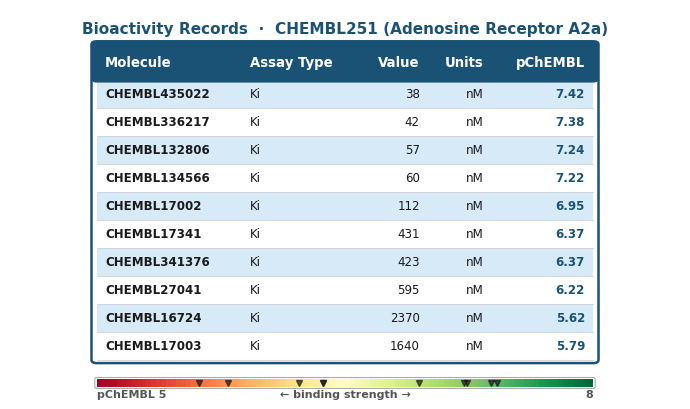

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

# ── Real ChEMBL251 (Adenosine A2a) activity records ──────────────────────────
columns = ['Molecule', 'Assay Type', 'Value', 'Units', 'pChEMBL']
rows = [
    ('CHEMBL435022', 'Ki',   38,   'nM', 7.42),
    ('CHEMBL336217', 'Ki',   42,   'nM', 7.38),
    ('CHEMBL132806', 'Ki',   57,   'nM', 7.24),
    ('CHEMBL134566', 'Ki',   60,   'nM', 7.22),
    ('CHEMBL17002',  'Ki',  112,   'nM', 6.95),
    ('CHEMBL17341',  'Ki',  431,   'nM', 6.37),
    ('CHEMBL341376', 'Ki',  423,   'nM', 6.37),
    ('CHEMBL27041',  'Ki',  595,   'nM', 6.22),
    ('CHEMBL16724',  'Ki', 2370,   'nM', 5.62),
    ('CHEMBL17003',  'Ki', 1640,   'nM', 5.79),
]

# ── Measure actual content widths using a temporary renderer ──────────────────
_fig_tmp, _ax_tmp = plt.subplots(figsize=(7, 4.2))
_renderer = _fig_tmp.canvas.get_renderer()

FONT_SIZE = 8.5
HDR_FONT  = 9.5

def _text_width_frac(ax, txt, fs):
    """Return text width as a fraction of axes width."""
    t = ax.text(0, 0, txt, fontsize=fs, fontweight='bold')
    bb = t.get_window_extent(renderer=_renderer)
    ax_bb = ax.get_window_extent(renderer=_renderer)
    t.remove()
    return bb.width / ax_bb.width

# For each column find the widest entry (header or data)
raw_widths = []
for ci, col_name in enumerate(columns):
    max_w = _text_width_frac(_ax_tmp, col_name, HDR_FONT)
    for row in rows:
        cell = str(row[ci])
        w = _text_width_frac(_ax_tmp, cell, FONT_SIZE)
        if w > max_w:
            max_w = w
    raw_widths.append(max_w)

plt.close(_fig_tmp)

# Add per-cell horizontal padding (keep absolute, don't normalise to 1.0)
PAD = 0.012  # fraction padding each side
padded = [w + 2 * PAD for w in raw_widths]
TABLE_W = sum(padded)          # table width = exact sum of padded columns
TABLE_X = (1.0 - TABLE_W) / 2  # centre the table horizontally

# Column widths & x-offsets are now in axes-fraction units (not relative to TABLE_W)
col_widths_abs = padded                             # absolute width per column
col_xs_abs     = np.cumsum([0.0] + padded[:-1])     # absolute x offset within table

# ── Layout constants ──────────────────────────────────────────────────────────
BLUE_H  = '#1A5276'
BLUE_L  = '#D6EAF8'
WHITE   = '#FFFFFF'
TEXT_D  = '#1a1a1a'
TEXT_H  = '#FFFFFF'
ACCENT  = '#1A5276'

ROW_H   = 0.072
HDR_H   = 0.090
N_ROWS  = len(rows)

fig, ax = plt.subplots(figsize=(7, 4.2), facecolor='white')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# ── Title ─────────────────────────────────────────────────────────────────────
ax.text(0.5, 0.97,
        'Bioactivity Records  ·  CHEMBL251 (Adenosine Receptor A2a)',
        ha='center', va='top', fontsize=11, color=BLUE_H)

TOP_Y = 0.91

# ── Header row ────────────────────────────────────────────────────────────────
ax.add_patch(FancyBboxPatch(
    (TABLE_X, TOP_Y - HDR_H), TABLE_W, HDR_H,
    boxstyle='round,pad=0.008', facecolor=BLUE_H,
    edgecolor='none', zorder=3))

for ci, (col, cw, cx) in enumerate(zip(columns, col_widths_abs, col_xs_abs)):
    align = 'right' if ci >= 2 else 'left'
    if align == 'right':
        xpos = TABLE_X + cx + cw - PAD
    else:
        xpos = TABLE_X + cx + PAD
    ax.text(xpos, TOP_Y - HDR_H / 2, col,
            ha=align, va='center', fontsize=HDR_FONT, fontweight='bold',
            color=TEXT_H, zorder=4)

# ── Data rows ─────────────────────────────────────────────────────────────────
for ri, (mol, atype, val, unit, pch) in enumerate(rows):
    ry = TOP_Y - HDR_H - (ri + 1) * ROW_H
    fc = BLUE_L if ri % 2 == 0 else WHITE

    ax.add_patch(FancyBboxPatch(
        (TABLE_X, ry), TABLE_W, ROW_H,
        boxstyle='square,pad=0', facecolor=fc,
        edgecolor='none', zorder=2))

    cell_vals = [mol, atype, str(val), unit, str(pch)]
    for ci, (cval, cw, cx) in enumerate(zip(cell_vals, col_widths_abs, col_xs_abs)):
        align = 'right' if ci >= 2 else 'left'
        bold  = ci == 0 or ci == 4
        color = ACCENT if ci == 4 else TEXT_D
        if align == 'right':
            xpos = TABLE_X + cx + cw - PAD
        else:
            xpos = TABLE_X + cx + PAD
        ax.text(xpos, ry + ROW_H / 2, cval,
                ha=align, va='center', fontsize=FONT_SIZE,
                fontweight='bold' if bold else 'normal',
                color=color, zorder=3)

    # Thin divider line
    ax.plot([TABLE_X, TABLE_X + TABLE_W], [ry, ry],
            color='#D0D0D0', lw=0.6, zorder=3)

# ── Outer border ──────────────────────────────────────────────────────────────
table_bottom = TOP_Y - HDR_H - N_ROWS * ROW_H
ax.add_patch(FancyBboxPatch(
    (TABLE_X, table_bottom), TABLE_W, TOP_Y - table_bottom,
    boxstyle='round,pad=0.008', facecolor='none',
    edgecolor=BLUE_H, linewidth=1.8, zorder=5))

# ── pChEMBL colour bar legend ─────────────────────────────────────────────────
bar_x = TABLE_X
bar_y = table_bottom - 0.07
bar_w = TABLE_W
bar_h = 0.022
cmap  = plt.cm.RdYlGn
for i in range(100):
    ax.add_patch(mpatches.Rectangle(
        (bar_x + i/100 * bar_w, bar_y), bar_w/100, bar_h,
        facecolor=cmap(i/99), edgecolor='none', zorder=3))
ax.add_patch(FancyBboxPatch((bar_x, bar_y), bar_w, bar_h,
    boxstyle='round,pad=0.003', facecolor='none',
    edgecolor='#AAA', linewidth=0.8, zorder=4))
ax.text(bar_x,           bar_y - 0.025, 'pChEMBL 5',  ha='left',   fontsize=8, color='#555')
ax.text(bar_x + bar_w/2, bar_y - 0.025, '← binding strength →', ha='center', fontsize=8, color='#555')
ax.text(bar_x + bar_w,   bar_y - 0.025, '8',          ha='right',  fontsize=8, color='#555')

# Marker for each row's pChEMBL on the bar
for ri, (*_, pch) in enumerate(rows):
    norm = (pch - 5.0) / (8.0 - 5.0)
    norm = max(0, min(1, norm))
    bx   = bar_x + norm * bar_w
    ax.plot(bx, bar_y + bar_h/2, 'v', ms=5,
            color='#1a1a1a', zorder=5, alpha=0.7)

fig.tight_layout()
plt.savefig('../figs/abstract_activity_table.png', dpi=180, bbox_inches='tight',
            facecolor='white')
plt.show()

## Curation Engine – Simplified Workflow

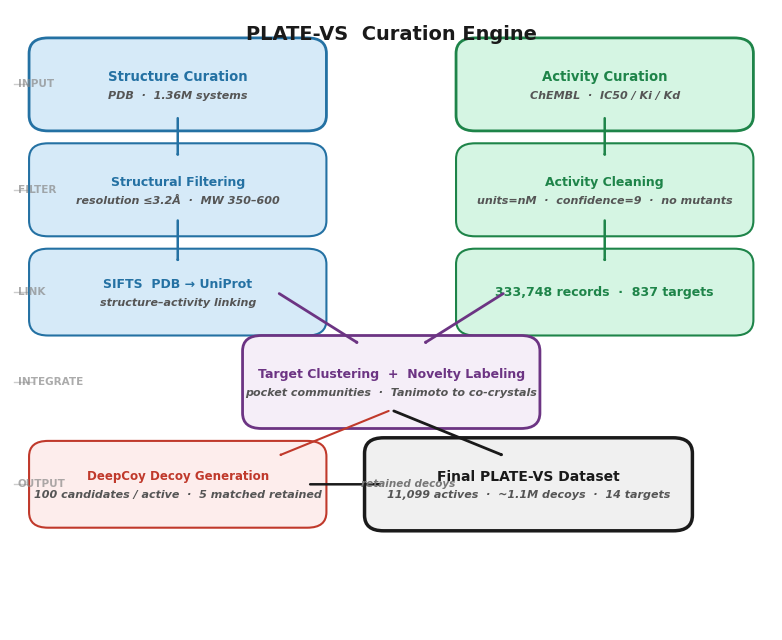

In [13]:
# ── Simplified Curation Engine Workflow ──────────────────────────────────────
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

# ── Palette ───────────────────────────────────────────────────────────────────
C = dict(
    struct_b = '#2471A3', struct_f = '#D6EAF8',   # blue  – structures
    act_b    = '#1E8449', act_f    = '#D5F5E3',   # green – activities
    merge_b  = '#6C3483', merge_f  = '#F5EEF8',   # purple – integration
    clust_b  = '#B7770D', clust_f  = '#FEF9E7',   # amber  – clustering
    decoy_b  = '#C0392B', decoy_f  = '#FDEDEC',   # red    – decoys
    final_b  = '#1a1a1a', final_f  = '#F0F0F0',   # dark   – output
    arrow    = '#555555',
)

fig, ax = plt.subplots(figsize=(8, 6.5), facecolor='white')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

# ── Helper functions ──────────────────────────────────────────────────────────
def box(ax, cx, cy, w, h, title, subtitle='', fc='#fff', bc='#333',
        title_fs=9.5, sub_fs=8.0, lw=2.0, radius=0.025):
    x0, y0 = cx - w/2, cy - h/2
    ax.add_patch(FancyBboxPatch((x0, y0), w, h,
        boxstyle=f'round,pad={radius}', facecolor=fc, edgecolor=bc,
        linewidth=lw, zorder=3, transform=ax.transAxes))
    ty = cy + (0.012 if subtitle else 0)
    ax.text(cx, ty, title, ha='center', va='center',
            fontsize=title_fs, fontweight='bold', color=bc,
            transform=ax.transAxes, zorder=4)
    if subtitle:
        ax.text(cx, cy - 0.018, subtitle, ha='center', va='center',
                fontsize=sub_fs, color='#555', style='italic',
                transform=ax.transAxes, zorder=4)

def arrow(ax, x0, y0, x1, y1, color='#555', lw=1.8, label=''):
    ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->,head_width=0.018,head_length=0.014',
                                color=color, lw=lw), zorder=5)
    if label:
        mx, my = (x0+x1)/2, (y0+y1)/2
        ax.text(mx + 0.02, my, label, ha='left', va='center',
                fontsize=7.5, color='#777', style='italic',
                transform=ax.transAxes, zorder=6)

# ══════════════════════════════════════════════════════════════════════════════
# ROW 1  –  Two input streams
# ══════════════════════════════════════════════════════════════════════════════
box(ax, 0.22, 0.88, 0.34, 0.10,
    'Structure Curation',
    'PDB  ·  1.36M systems',
    fc=C['struct_f'], bc=C['struct_b'])

box(ax, 0.78, 0.88, 0.34, 0.10,
    'Activity Curation',
    'ChEMBL  ·  IC50 / Ki / Kd',
    fc=C['act_f'], bc=C['act_b'])

# ROW 2  –  Filtering steps
box(ax, 0.22, 0.71, 0.34, 0.10,
    'Structural Filtering',
    'resolution ≤3.2Å  ·  MW 350–600',
    fc=C['struct_f'], bc=C['struct_b'], lw=1.5, title_fs=9)

box(ax, 0.78, 0.71, 0.34, 0.10,
    'Activity Cleaning',
    'units=nM  ·  confidence=9  ·  no mutants',
    fc=C['act_f'], bc=C['act_b'], lw=1.5, title_fs=9)

# Arrows row1 → row2
arrow(ax, 0.22, 0.83, 0.22, 0.76, C['struct_b'])
arrow(ax, 0.78, 0.83, 0.78, 0.76, C['act_b'])

# ROW 3  –  SIFTS merge  &  record counts
box(ax, 0.22, 0.545, 0.34, 0.09,
    'SIFTS  PDB → UniProt',
    'structure–activity linking',
    fc=C['struct_f'], bc=C['struct_b'], lw=1.5, title_fs=9)

box(ax, 0.78, 0.545, 0.34, 0.09,
    '333,748 records  ·  837 targets',
    '',
    fc=C['act_f'], bc=C['act_b'], lw=1.5, title_fs=9)

arrow(ax, 0.22, 0.665, 0.22, 0.59, C['struct_b'])
arrow(ax, 0.78, 0.665, 0.78, 0.59, C['act_b'])

# ── Convergence arrows → integration box ─────────────────────────────────────
arrow(ax, 0.35, 0.545, 0.46, 0.46, C['merge_b'], lw=2.0)
arrow(ax, 0.65, 0.545, 0.54, 0.46, C['merge_b'], lw=2.0)

# ROW 4  –  Integration
box(ax, 0.50, 0.40, 0.34, 0.10,
    'Target Clustering  +  Novelty Labeling',
    'pocket communities  ·  Tanimoto to co-crystals',
    fc=C['merge_f'], bc=C['merge_b'], title_fs=9)

# ROW 5  –  Decoy generation (side branch) + final dataset
box(ax, 0.22, 0.235, 0.34, 0.09,
    'DeepCoy Decoy Generation',
    '100 candidates / active  ·  5 matched retained',
    fc=C['decoy_f'], bc=C['decoy_b'], lw=1.5, title_fs=8.5)

arrow(ax, 0.50, 0.355, 0.35, 0.28, C['decoy_b'], lw=1.5)

# Final dataset box (centred)
box(ax, 0.68, 0.235, 0.38, 0.10,
    'Final PLATE-VS Dataset',
    '11,099 actives  ·  ~1.1M decoys  ·  14 targets',
    fc=C['final_f'], bc=C['final_b'], title_fs=10, lw=2.5)

arrow(ax, 0.50, 0.355, 0.65, 0.28, C['final_b'], lw=2.0)
arrow(ax, 0.39, 0.235, 0.49, 0.235, C['final_b'], lw=1.8,
      label='retained decoys')

# ── Section labels (left margin) ──────────────────────────────────────────────
for y, txt, color in [
    (0.88, 'INPUT',       '#888'),
    (0.71, 'FILTER',      '#888'),
    (0.545,'LINK',        '#888'),
    (0.40, 'INTEGRATE',   '#888'),
    (0.235,'OUTPUT',      '#888'),
]:
    ax.text(0.01, y, txt, ha='left', va='center',
            fontsize=7.5, color=color, fontweight='bold',
            transform=ax.transAxes, alpha=0.7)
    ax.plot([0.005, 0.03], [y, y], color='#CCC', lw=1.0,
            transform=ax.transAxes)

# ── Title ─────────────────────────────────────────────────────────────────────
ax.text(0.50, 0.975, 'PLATE-VS  Curation Engine',
        ha='center', va='top', fontsize=14, fontweight='bold',
        color='#1a1a1a', transform=ax.transAxes)

fig.tight_layout()
plt.savefig('../figs/abstract_curation_workflow.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()


## Synthetic Accessibility: Actives vs DeepCoy Decoys

Computing SA scores: 100%|██████████| 1387/1387 [09:10<00:00,  2.52it/s]


SA scores: 2,289,638 molecules  (269,118 actives, 2,020,520 decoys)
            count  mean   std   min   25%   50%   75%   max
role                                                       
Active   269118.0  3.05  0.72  1.03  2.55  2.93  3.45  7.93
Decoy   2020520.0  3.56  0.97  1.00  2.91  3.47  4.10  9.01
Saved  sa_score_actives_vs_decoys  →  ../data/output/figures/diagram_components


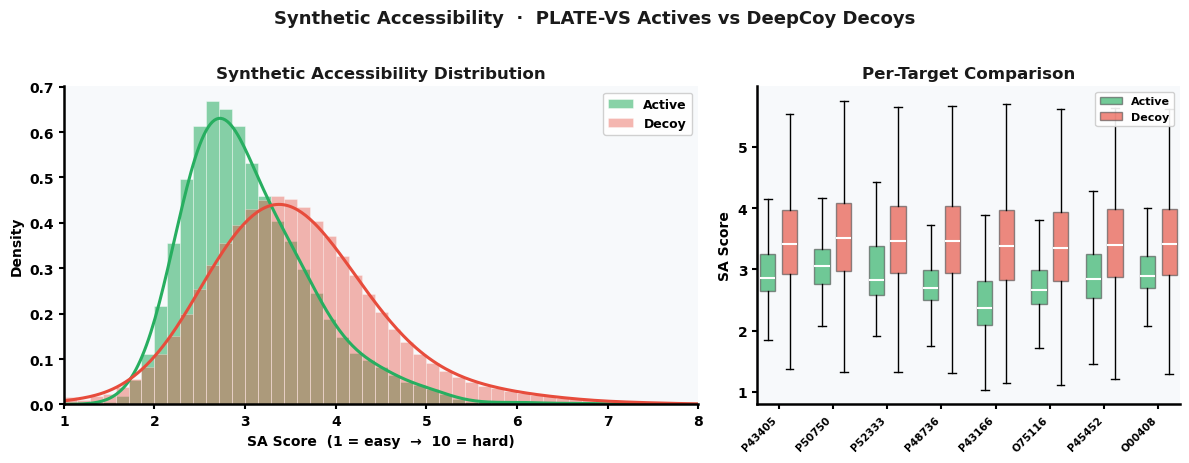

In [15]:
# ── Synthetic Accessibility: Actives vs Decoys ───────────────────────────────
import sys, os
from rdkit import RDConfig
from scipy.stats import gaussian_kde

# sascorer lives in RDKit's Contrib dir — not on sys.path by default
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

# ── Collect SA scores across all targets ──────────────────────────────────────
decoy_root = DATA_DIR / 'chembl_affinity'
target_dirs = sorted([d for d in decoy_root.iterdir()
                      if d.is_dir() and d.name.startswith('uniprot_')])

records = []

for tdir in tqdm(target_dirs, desc='Computing SA scores'):
    target_id = tdir.name.replace('uniprot_', '')
    decoy_file = tdir / f'deepcoy_output/{target_id}_generated_decoys.txt'
    if not decoy_file.exists():
        continue

    df_dec = pd.read_csv(decoy_file, sep=' ', header=None,
                         names=['active_smi', 'decoy_smi'])

    for smi in df_dec['active_smi'].dropna().unique():
        mol = Chem.MolFromSmiles(smi)
        if mol:
            records.append((target_id, 'Active',
                            sascorer.calculateScore(mol)))

    for smi in df_dec['decoy_smi'].dropna().unique():
        mol = Chem.MolFromSmiles(smi)
        if mol:
            records.append((target_id, 'Decoy',
                            sascorer.calculateScore(mol)))

sa_df = pd.DataFrame(records, columns=['target', 'role', 'sa_score'])
print(f"SA scores: {len(sa_df):,} molecules  "
      f"({(sa_df.role=='Active').sum():,} actives, "
      f"{(sa_df.role=='Decoy').sum():,} decoys)")
print(sa_df.groupby('role')['sa_score'].describe().round(2))

# ── Colours (consistent with abstract palette) ───────────────────────────────
C_ACT   = PALETTE['activity']   # green
C_DEC   = PALETTE['decoy']      # red
GREY_BG = '#F7F9FB'

# ══════════════════════════════════════════════════════════════════════════════
# Two-panel figure
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor='white',
                         gridspec_kw={'width_ratios': [3, 2]})

# ── Left: histogram + KDE ────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(GREY_BG)
bins = np.linspace(1, 8, 50)

for role, color, alpha in [('Active', C_ACT, 0.55), ('Decoy', C_DEC, 0.40)]:
    vals = sa_df.loc[sa_df.role == role, 'sa_score'].values
    ax.hist(vals, bins=bins, density=True, alpha=alpha, color=color,
            edgecolor='white', linewidth=0.5, label=role)
    kde = gaussian_kde(vals, bw_method=0.25)
    xs  = np.linspace(1, 8, 300)
    ax.plot(xs, kde(xs), color=color, lw=2.2)

ax.set_xlabel('SA Score  (1 = easy  →  10 = hard)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Synthetic Accessibility Distribution', fontsize=12,
             fontweight='bold', color='#1a1a1a')
ax.legend(framealpha=0.9, fontsize=9, edgecolor='#CCC')
ax.set_xlim(1, 8)

# ── Right: per-target paired box plot ─────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(GREY_BG)

top_targets = (sa_df.groupby('target').size()
               .sort_values(ascending=False).head(8).index.tolist())
sub = sa_df[sa_df.target.isin(top_targets)].copy()

positions, colors_bp, data_list = [], [], []
pos = 0
for tid in top_targets:
    for role, color in [('Active', C_ACT), ('Decoy', C_DEC)]:
        vals = sub.loc[(sub.target == tid) & (sub.role == role), 'sa_score']
        if len(vals) == 0:
            continue
        data_list.append(vals.values)
        positions.append(pos)
        colors_bp.append(color)
        pos += 1
    pos += 0.5

bp = ax2.boxplot(data_list, positions=positions, widths=0.7,
                 patch_artist=True, showfliers=False,
                 medianprops=dict(color='white', lw=1.5))
for patch, c in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(c)
    patch.set_alpha(0.65)
    patch.set_edgecolor('#555')

tick_pos, idx = [], 0
for tid in top_targets:
    n = sum(1 for r in ['Active', 'Decoy']
            if len(sub.loc[(sub.target == tid) & (sub.role == r)]) > 0)
    tick_pos.append(positions[idx] + (n - 1) / 2)
    idx += n

ax2.set_xticks(tick_pos)
ax2.set_xticklabels(top_targets, rotation=45, ha='right', fontsize=7.5)
ax2.set_ylabel('SA Score', fontsize=10)
ax2.set_title('Per-Target Comparison', fontsize=12,
              fontweight='bold', color='#1a1a1a')

h_act = mpatches.Patch(facecolor=C_ACT, alpha=0.65, edgecolor='#555', label='Active')
h_dec = mpatches.Patch(facecolor=C_DEC, alpha=0.65, edgecolor='#555', label='Decoy')
ax2.legend(handles=[h_act, h_dec], fontsize=8, loc='upper right',
           framealpha=0.9, edgecolor='#CCC')

fig.suptitle('Synthetic Accessibility  ·  PLATE-VS Actives vs DeepCoy Decoys',
             fontsize=13, fontweight='bold', color='#1a1a1a', y=1.02)
fig.tight_layout()
save_fig(fig, 'sa_score_actives_vs_decoys')
plt.show()

Saved  sa_score_actives_vs_decoys  →  ../data/output/figures/diagram_components


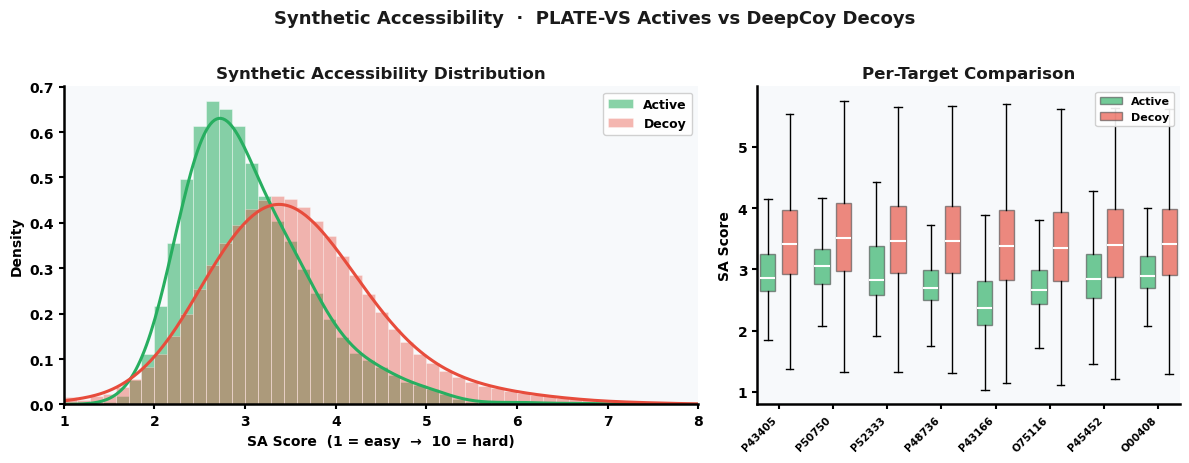

In [ ]:
# ── Synthetic Accessibility: Actives vs Decoys ───────────────────────────────
import sys, os
from rdkit import RDConfig
from scipy.stats import gaussian_kde

# sascorer lives in RDKit's Contrib dir — not on sys.path by default
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

# ══════════════════════════════════════════════════════════════════════════════
# Two-panel figure
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor='white',
                         gridspec_kw={'width_ratios': [3, 2]})

# ── Left: histogram + KDE ────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(GREY_BG)
bins = np.linspace(1, 8, 50)

for role, color, alpha in [('Active', C_ACT, 0.55), ('Decoy', C_DEC, 0.40)]:
    vals = sa_df.loc[sa_df.role == role, 'sa_score'].values
    ax.hist(vals, bins=bins, density=True, alpha=alpha, color=color,
            edgecolor='white', linewidth=0.5, label=role)
    kde = gaussian_kde(vals, bw_method=0.25)
    xs  = np.linspace(1, 8, 300)
    ax.plot(xs, kde(xs), color=color, lw=2.2)

ax.set_xlabel('SA Score  (1 = easy  →  10 = hard)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.set_title('Synthetic Accessibility Distribution', fontsize=12,
             fontweight='bold', color='#1a1a1a')
ax.legend(framealpha=0.9, fontsize=9, edgecolor='#CCC')
ax.set_xlim(1, 8)

# ── Right: per-target paired box plot ─────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(GREY_BG)

top_targets = (sa_df.groupby('target').size()
               .sort_values(ascending=False).head(8).index.tolist())
sub = sa_df[sa_df.target.isin(top_targets)].copy()

positions, colors_bp, data_list = [], [], []
pos = 0
for tid in top_targets:
    for role, color in [('Active', C_ACT), ('Decoy', C_DEC)]:
        vals = sub.loc[(sub.target == tid) & (sub.role == role), 'sa_score']
        if len(vals) == 0:
            continue
        data_list.append(vals.values)
        positions.append(pos)
        colors_bp.append(color)
        pos += 1
    pos += 0.5

bp = ax2.boxplot(data_list, positions=positions, widths=0.7,
                 patch_artist=True, showfliers=False,
                 medianprops=dict(color='white', lw=1.5))
for patch, c in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(c)
    patch.set_alpha(0.65)
    patch.set_edgecolor('#555')

tick_pos, idx = [], 0
for tid in top_targets:
    n = sum(1 for r in ['Active', 'Decoy']
            if len(sub.loc[(sub.target == tid) & (sub.role == r)]) > 0)
    tick_pos.append(positions[idx] + (n - 1) / 2)
    idx += n

ax2.set_xticks(tick_pos)
ax2.set_xticklabels(top_targets, rotation=45, ha='right', fontsize=7.5)
ax2.set_ylabel('SA Score', fontsize=10)
ax2.set_title('Per-Target Comparison', fontsize=12,
            color='#1a1a1a')

h_act = mpatches.Patch(facecolor=C_ACT, alpha=0.65, edgecolor='#555', label='Active')
h_dec = mpatches.Patch(facecolor=C_DEC, alpha=0.65, edgecolor='#555', label='Decoy')
ax2.legend(handles=[h_act, h_dec], fontsize=8, loc='upper right',
           framealpha=0.9, edgecolor='#CCC')

# fig.suptitle('Synthetic Accessibility  ·  PLATE-VS Actives vs DeepCoy Decoys',
#              fontsize=13, color='#1a1a1a', y=1.02)

fig.tight_layout()
save_fig(fig, 'sa_score_actives_vs_decoys')
plt.show()